# NCAA Basketball Network Project — Baseline Notebook

This notebook sets up the **baseline network analysis** for the final paper.

## Paper direction
We are treating NCAA regular-season play as a **network science** problem rather than a bracket-prediction problem.

### Core idea
- **Nodes** = teams  
- **Undirected weighted edges** = teams played each other, weighted by number of meetings  
- **Directed weighted edges** = loser → winner, weighted by number of wins  

### Main research direction
We want to study how conference structure shapes:
1. **community structure**,
2. **bridge teams / bridge conferences**, and
3. **global comparability / embeddedness** in the national schedule network.

This notebook focuses on the **baseline descriptive graphs and tables** that will likely support the first draft of the paper.

## 0. Notebook roadmap

This notebook does the following:

1. Loads the Kaggle data files we need.
2. Builds a season-level **schedule graph** and **results graph**.
3. Computes cross-season summary statistics.
4. Produces baseline figures for a selected season:
   - conference-colored schedule graph,
   - degree and weighted-degree histograms,
   - conference meta-graph,
   - top centrality tables,
   - weighted degree vs. betweenness scatter.
5. Saves figures and tables into an `outputs/` folder.

Later notebooks / sections can extend this with:
- community detection,
- null model comparisons,
- Laplacian-based comparability scores,
- optional use of detailed box-score data.

In [9]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from networkx.algorithms.community.quality import modularity

plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

In [10]:
# ----------------------------
# Paths / configuration
# ----------------------------
DATA_DIR = Path(".")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TEAMS_PATH = DATA_DIR / "MTeams.csv"
CONF_PATH = DATA_DIR / "MTeamConferences.csv"
REG_COMPACT_PATH = DATA_DIR / "MRegularSeasonCompactResults.csv"
REG_DETAILED_PATH = DATA_DIR / "MRegularSeasonDetailedResults.csv"  # optional extension

# Main season to visualize in detail
SEASON = 2025

# If True, later extensions can use detailed results.
USE_DETAILED_RESULTS = False

## 1. Load data

In [11]:
teams = pd.read_csv(TEAMS_PATH)
team_confs = pd.read_csv(CONF_PATH)
reg_compact = pd.read_csv(REG_COMPACT_PATH)

# Optional file for later feature extensions (not used in baseline analysis)
reg_detailed = None
if USE_DETAILED_RESULTS and REG_DETAILED_PATH.exists():
    reg_detailed = pd.read_csv(REG_DETAILED_PATH)

print("teams:", teams.shape)
print("team_confs:", team_confs.shape)
print("reg_compact:", reg_compact.shape)
if reg_detailed is not None:
    print("reg_detailed:", reg_detailed.shape)

teams: (380, 4)
team_confs: (13388, 3)
reg_compact: (192930, 8)


In [12]:
display(teams.head())
display(team_confs.head())
display(reg_compact.head())

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2025
1,1102,Air Force,1985,2025
2,1103,Akron,1985,2025
3,1104,Alabama,1985,2025
4,1105,Alabama A&M,2000,2025


,Season,TeamID,ConfAbbrev
0,1985,1102,wac
1,1985,1103,ovc
2,1985,1104,sec
3,1985,1106,swac
4,1985,1108,swac


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


## 2. Basic validation
We use the intersection of seasons that appear in both:
- regular-season results, and
- conference membership.

In [13]:
valid_seasons = sorted(set(reg_compact["Season"]).intersection(set(team_confs["Season"])))
print(f"Valid seasons with conference labels: {valid_seasons[0]} to {valid_seasons[-1]} ({len(valid_seasons)} seasons)")

if SEASON not in valid_seasons:
    raise ValueError(f"SEASON={SEASON} is not in the valid intersection of seasons.")

Valid seasons with conference labels: 1985 to 2025 (41 seasons)


## 3. Helper functions
These functions build the core graph objects and summary tables.

In [14]:
team_name_map = teams.set_index("TeamID")["TeamName"].to_dict()

def build_season_frames(season, reg_df=reg_compact, conf_df=team_confs):
    games = reg_df.loc[reg_df["Season"] == season].copy()
    confs = conf_df.loc[conf_df["Season"] == season].copy()

    # undirected pair for schedule graph
    games["TeamA"] = games[["WTeamID", "LTeamID"]].min(axis=1)
    games["TeamB"] = games[["WTeamID", "LTeamID"]].max(axis=1)

    return games, confs

def build_graphs_for_season(season, reg_df=reg_compact, conf_df=team_confs):
    games, confs = build_season_frames(season, reg_df=reg_df, conf_df=conf_df)
    conf_map = confs.set_index("TeamID")["ConfAbbrev"].to_dict()

    # --- Undirected schedule graph ---
    edge_weights = (
        games.groupby(["TeamA", "TeamB"])
        .size()
        .reset_index(name="weight")
    )
    G = nx.Graph()
    for row in edge_weights.itertuples(index=False):
        G.add_edge(int(row.TeamA), int(row.TeamB), weight=int(row.weight))

    # --- Directed results graph: loser -> winner ---
    result_weights = (
        games.groupby(["LTeamID", "WTeamID"])
        .size()
        .reset_index(name="weight")
    )
    DG = nx.DiGraph()
    for row in result_weights.itertuples(index=False):
        DG.add_edge(int(row.LTeamID), int(row.WTeamID), weight=int(row.weight))

    # Attach metadata
    node_ids = set(G.nodes()) | set(DG.nodes())
    attrs = {
        int(team_id): {
            "TeamName": team_name_map.get(int(team_id), str(team_id)),
            "Conference": conf_map.get(int(team_id), "unknown")
        }
        for team_id in node_ids
    }
    nx.set_node_attributes(G, attrs)
    nx.set_node_attributes(DG, attrs)

    return G, DG, games, confs

def build_conference_meta_graph(G):
    """Conference-level graph based on interconference games.
    Node = conference
    Edge weight = total number of regular-season games between two conferences
    """
    conf_edge_weights = {}
    conf_sizes = {}

    for node, data in G.nodes(data=True):
        conf = data.get("Conference", "unknown")
        conf_sizes[conf] = conf_sizes.get(conf, 0) + 1

    for u, v, data in G.edges(data=True):
        cu = G.nodes[u].get("Conference", "unknown")
        cv = G.nodes[v].get("Conference", "unknown")
        if cu == cv:
            continue
        a, b = sorted([cu, cv])
        conf_edge_weights[(a, b)] = conf_edge_weights.get((a, b), 0) + data.get("weight", 1)

    CG = nx.Graph()
    for conf, size in conf_sizes.items():
        CG.add_node(conf, size=size)
    for (a, b), w in conf_edge_weights.items():
        CG.add_edge(a, b, weight=w)
    return CG

def season_summary_row(season):
    G, DG, games, confs = build_graphs_for_season(season)

    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)
    n_components = nx.number_connected_components(G)
    components = list(nx.connected_components(G))
    gcc_nodes = max(components, key=len)
    G_gcc = G.subgraph(gcc_nodes).copy()

    communities = {}
    for node, data in G.nodes(data=True):
        communities.setdefault(data.get("Conference", "unknown"), []).append(node)
    conference_partition = list(communities.values())

    within_weight = 0
    between_weight = 0
    for u, v, data in G.edges(data=True):
        w = data.get("weight", 1)
        if G.nodes[u].get("Conference") == G.nodes[v].get("Conference"):
            within_weight += w
        else:
            between_weight += w

    total_weight = within_weight + between_weight

    return {
        "Season": season,
        "Teams": n,
        "Games": len(games),
        "Edges": m,
        "Density": density,
        "Components": n_components,
        "GiantComponentShare": len(gcc_nodes) / n if n else np.nan,
        "AvgPathLength_GCC": nx.average_shortest_path_length(G_gcc) if len(G_gcc) > 1 else np.nan,
        "AvgClustering": nx.average_clustering(G),
        "ConferenceModularity": modularity(G, conference_partition, weight="weight"),
        "WithinConfGameFrac": within_weight / total_weight if total_weight else np.nan,
        "BetweenConfGameFrac": between_weight / total_weight if total_weight else np.nan,
        "MeanDegree": np.mean([d for _, d in G.degree()]),
        "MeanWeightedDegree": np.mean([d for _, d in G.degree(weight="weight")]),
        "DirectedEdges": DG.number_of_edges(),
    }

def centrality_table(G, DG, top_n=15):
    weighted_degree = dict(G.degree(weight="weight"))
    degree = dict(G.degree())
    betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)
    closeness = nx.closeness_centrality(G)
    pagerank = nx.pagerank(DG, weight="weight")

    rows = []
    for node in G.nodes():
        rows.append({
            "TeamID": node,
            "TeamName": G.nodes[node].get("TeamName"),
            "Conference": G.nodes[node].get("Conference"),
            "Degree": degree.get(node, np.nan),
            "WeightedDegree": weighted_degree.get(node, np.nan),
            "Betweenness": betweenness.get(node, np.nan),
            "Closeness": closeness.get(node, np.nan),
            "PageRank": pagerank.get(node, np.nan),
        })
    df = pd.DataFrame(rows)
    return df.sort_values(["WeightedDegree", "Betweenness"], ascending=False).reset_index(drop=True)

def within_between_conference_table(G):
    rows = []
    for u, v, data in G.edges(data=True):
        conf_u = G.nodes[u].get("Conference", "unknown")
        conf_v = G.nodes[v].get("Conference", "unknown")
        rows.append({
            "TeamU": u,
            "TeamV": v,
            "ConfU": conf_u,
            "ConfV": conf_v,
            "weight": data.get("weight", 1),
            "EdgeType": "Within" if conf_u == conf_v else "Between"
        })
    edge_df = pd.DataFrame(rows)
    summary = (
        edge_df.groupby("EdgeType")["weight"]
        .agg(["sum", "mean", "count"])
        .rename(columns={"sum": "TotalGames", "mean": "AvgWeight", "count": "NumEdges"})
        .reset_index()
    )
    total_games = summary["TotalGames"].sum()
    summary["GameShare"] = summary["TotalGames"] / total_games if total_games else np.nan
    return edge_df, summary

def conference_connectivity_table(CG):
    rows = []
    for conf in CG.nodes():
        rows.append({
            "Conference": conf,
            "TeamsInSeason": CG.nodes[conf].get("size", np.nan),
            "InterconfDegree": CG.degree(conf),
            "InterconfWeightedDegree": CG.degree(conf, weight="weight"),
        })
    df = pd.DataFrame(rows)
    return df.sort_values("InterconfWeightedDegree", ascending=False).reset_index(drop=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved: {path}")

def finish_figure(title=None, filename=None):
    if title:
        plt.title(title)
    plt.tight_layout()
    if filename:
        path = OUTPUT_DIR / filename
        plt.savefig(path, bbox_inches="tight")
        print(f"Saved: {path}")
    plt.show()

## 4. Cross-season summary table
This gives paper-level context before we zoom into one season.

In [15]:
season_summary = pd.DataFrame([season_summary_row(season) for season in valid_seasons])
display(season_summary.head())
display(season_summary.tail())

save_table(season_summary, "season_summary")

,Season,Teams,Games,Edges,Density,Components,GiantComponentShare,AvgPathLength_GCC,AvgClustering,ConferenceModularity,WithinConfGameFrac,BetweenConfGameFrac,MeanDegree,MeanWeightedDegree,DirectedEdges
0,1985,282,3737,2407,0.060751,1,1.0,2.453345,0.278337,0.562981,0.597003,0.402997,17.070922,26.503546,2915
1,1986,283,3783,2431,0.060923,1,1.0,2.462522,0.284063,0.558324,0.590537,0.409463,17.180212,26.734982,2940
2,1987,290,3915,2544,0.060709,1,1.0,2.434459,0.267691,0.555434,0.586973,0.413027,17.544828,27.000000,3055
3,1988,290,3955,2585,0.061687,1,1.0,2.417039,0.268145,0.562373,0.594185,0.405815,17.827586,27.275862,3106
4,1989,293,4037,2659,0.062158,1,1.0,2.400603,0.254166,0.547867,0.580381,0.419619,18.150171,27.556314,3168


,Season,Teams,Games,Edges,Density,Components,GiantComponentShare,AvgPathLength_GCC,AvgClustering,ConferenceModularity,WithinConfGameFrac,BetweenConfGameFrac,MeanDegree,MeanWeightedDegree,DirectedEdges
36,2021,347,3855,2400,0.039979,1,1.0,2.998001,0.424473,0.741497,0.775616,0.224384,13.832853,22.219020,2909
37,2022,358,5345,3677,0.057540,1,1.0,2.427570,0.304124,0.622039,0.654443,0.345557,20.541899,29.860335,4269
38,2023,363,5602,3888,0.059175,1,1.0,2.384396,0.293057,0.609626,0.641735,0.358265,21.421488,30.865014,4527
39,2024,362,5607,3940,0.060299,1,1.0,2.378736,0.292734,0.602905,0.635456,0.364544,21.767956,30.977901,4582
40,2025,364,5641,4043,0.061196,1,1.0,2.374868,0.310107,0.611861,0.646339,0.353661,22.214286,30.994505,4624


Saved: outputs/season_summary.csv


## 5. Cross-season baseline figures
These are useful for the introduction / methods section of the short paper because they show the NCAA schedule network at a macro level over time.

Saved: outputs/teams_by_season.png


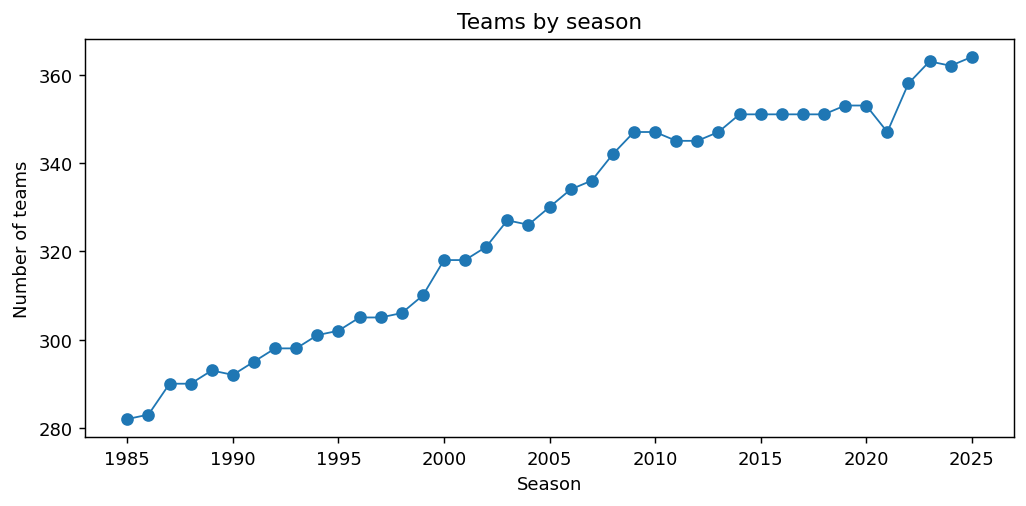

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(season_summary["Season"], season_summary["Teams"], marker="o", linewidth=1)
plt.xlabel("Season")
plt.ylabel("Number of teams")
finish_figure("Teams by season", "teams_by_season.png")

Saved: outputs/edges_by_season.png


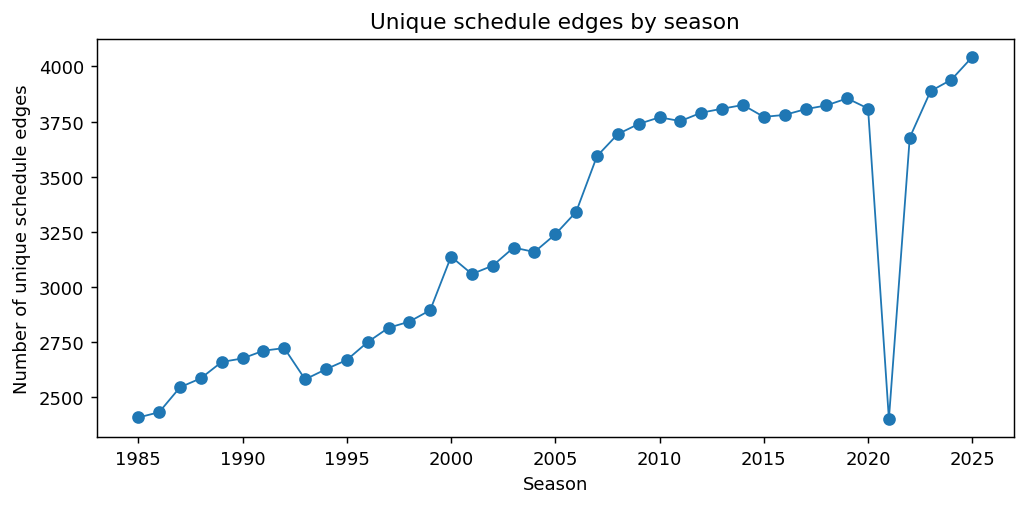

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(season_summary["Season"], season_summary["Edges"], marker="o", linewidth=1)
plt.xlabel("Season")
plt.ylabel("Number of unique schedule edges")
finish_figure("Unique schedule edges by season", "edges_by_season.png")

Saved: outputs/conference_modularity_by_season.png


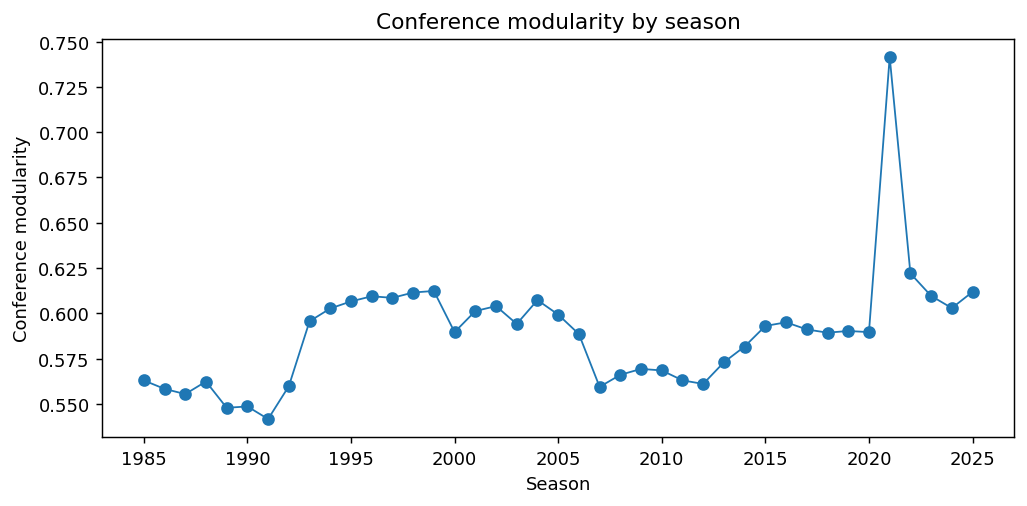

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(season_summary["Season"], season_summary["ConferenceModularity"], marker="o", linewidth=1)
plt.xlabel("Season")
plt.ylabel("Conference modularity")
finish_figure("Conference modularity by season", "conference_modularity_by_season.png")

Saved: outputs/between_conf_fraction_by_season.png


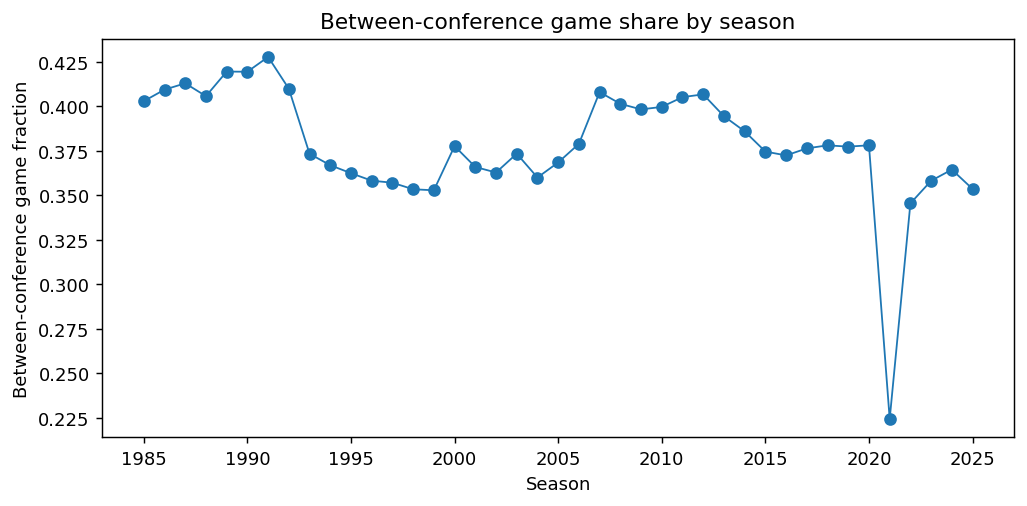

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(season_summary["Season"], season_summary["BetweenConfGameFrac"], marker="o", linewidth=1)
plt.xlabel("Season")
plt.ylabel("Between-conference game fraction")
finish_figure("Between-conference game share by season", "between_conf_fraction_by_season.png")

## 6. Build graphs for the selected season
This season will drive the main figures and tables in the baseline analysis.

In [20]:
G, DG, games_season, confs_season = build_graphs_for_season(SEASON)
CG = build_conference_meta_graph(G)

print(f"Selected season: {SEASON}")
print(f"Schedule graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Results graph:  {DG.number_of_nodes()} nodes, {DG.number_of_edges()} directed edges")
print(f"Conference meta-graph: {CG.number_of_nodes()} conference nodes, {CG.number_of_edges()} edges")

Selected season: 2025
Schedule graph: 364 nodes, 4043 edges
Results graph:  364 nodes, 4624 directed edges
Conference meta-graph: 31 conference nodes, 383 edges


In [21]:
season_row = season_summary.loc[season_summary["Season"] == SEASON].copy()
display(season_row)

,Season,Teams,Games,Edges,Density,Components,GiantComponentShare,AvgPathLength_GCC,AvgClustering,ConferenceModularity,WithinConfGameFrac,BetweenConfGameFrac,MeanDegree,MeanWeightedDegree,DirectedEdges
40,2025,364,5641,4043,0.061196,1,1.0,2.374868,0.310107,0.611861,0.646339,0.353661,22.214286,30.994505,4624


## 7. One-season descriptive tables

In [22]:
edge_df, edge_summary = within_between_conference_table(G)
centrality_df = centrality_table(G, DG, top_n=15)
conf_connectivity_df = conference_connectivity_table(CG)

display(edge_summary)
display(centrality_df.head(15))
display(conf_connectivity_df.head(15))

save_table(edge_summary, f"edge_type_summary_{SEASON}")
save_table(centrality_df, f"centrality_table_{SEASON}")
save_table(conf_connectivity_df, f"conference_connectivity_{SEASON}")

,EdgeType,TotalGames,AvgWeight,NumEdges,GameShare
0,Between,1995,1.005544,1984,0.353661
1,Within,3646,1.770763,2059,0.646339


,TeamID,TeamName,Conference,Degree,WeightedDegree,Betweenness,Closeness,PageRank
0,1458,Wisconsin,big_ten,28,35,0.005546,0.455458,0.007719
1,1314,North Carolina,acc,29,35,0.004969,0.446494,0.003566
2,1181,Duke,acc,28,34,0.006057,0.446494,0.009875
3,1397,Tennessee,sec,28,34,0.005658,0.444853,0.018163
4,1400,Texas,sec,28,34,0.005448,0.444853,0.007226
5,1160,Colorado,big_twelve,25,34,0.005282,0.435252,0.003224
6,1272,Memphis,aac,25,34,0.005177,0.443223,0.008874
7,1238,Jackson St,swac,24,34,0.005011,0.438406,0.000933
8,1222,Houston,big_twelve,26,34,0.004903,0.444308,0.008667
9,1112,Arizona,big_twelve,25,34,0.004708,0.449814,0.006440


,Conference,TeamsInSeason,InterconfDegree,InterconfWeightedDegree
0,sec,16,28,208
1,acc,18,30,199
2,big_ten,18,30,197
3,a_ten,15,27,176
4,big_twelve,16,28,171
5,caa,14,26,162
6,sun_belt,14,25,156
7,aac,13,27,150
8,a_sun,12,26,133
9,swac,12,23,133


Saved: outputs/edge_type_summary_2025.csv
Saved: outputs/centrality_table_2025.csv
Saved: outputs/conference_connectivity_2025.csv


## 8. Conference-colored schedule graph

This is one of the most important visual baselines for the paper.  
The graph should visually suggest:
- strong conference communities,
- sparse cross-conference bridges,
- potential bridge teams between communities.

Because there are many conferences, the legend is intentionally omitted in the first pass.  
Instead, we color each team by conference code.

Saved: outputs/schedule_graph_conference_2025.png


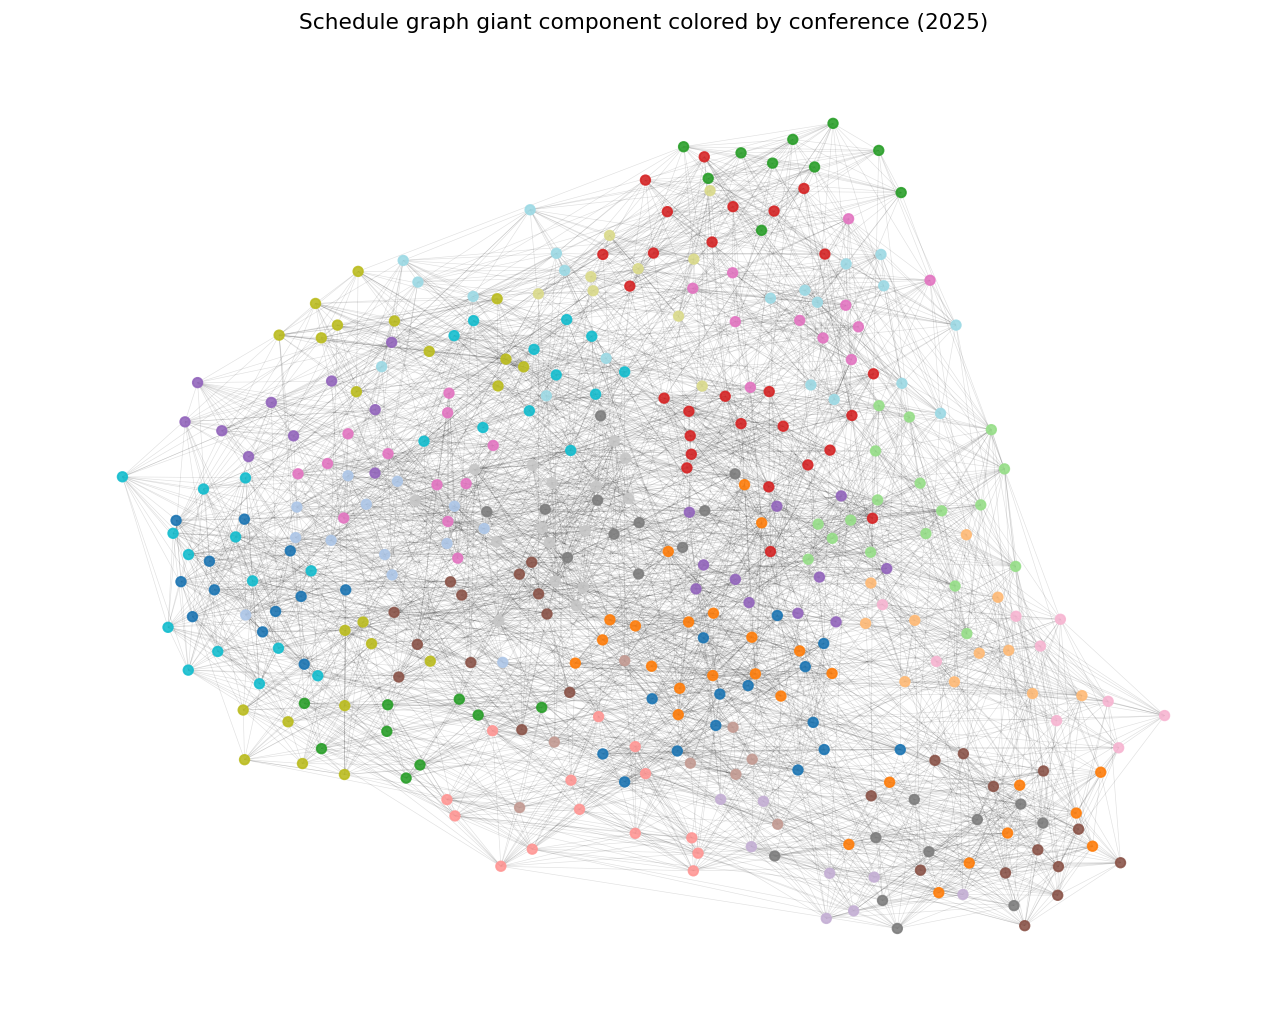

In [23]:
# Map conferences to integer colors
conf_codes = sorted({G.nodes[n].get("Conference", "unknown") for n in G.nodes()})
conf_to_int = {conf: i for i, conf in enumerate(conf_codes)}
node_colors = [conf_to_int[G.nodes[n].get("Conference", "unknown")] for n in G.nodes()]

# Use the giant component for a cleaner plot
gcc_nodes = max(nx.connected_components(G), key=len)
G_gcc = G.subgraph(gcc_nodes).copy()

conf_codes_gcc = sorted({G_gcc.nodes[n].get("Conference", "unknown") for n in G_gcc.nodes()})
conf_to_int_gcc = {conf: i for i, conf in enumerate(conf_codes_gcc)}
node_colors_gcc = [conf_to_int_gcc[G_gcc.nodes[n].get("Conference", "unknown")] for n in G_gcc.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_gcc, seed=42, k=0.22, iterations=80, weight="weight")
nx.draw_networkx_nodes(
    G_gcc,
    pos,
    node_size=28,
    node_color=node_colors_gcc,
    cmap=plt.cm.tab20,
    alpha=0.9,
)
nx.draw_networkx_edges(
    G_gcc,
    pos,
    width=0.35,
    alpha=0.12,
)
plt.axis("off")
finish_figure(f"Schedule graph giant component colored by conference ({SEASON})",
              f"schedule_graph_conference_{SEASON}.png")

## 9. Degree distribution baselines
These histograms help describe network heterogeneity.

Saved: outputs/degree_hist_2025.png


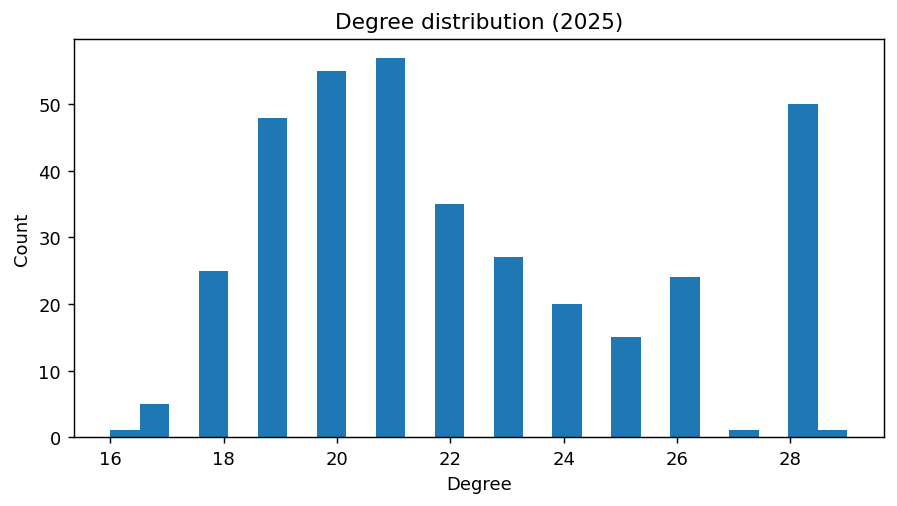

In [24]:
degree_values = [d for _, d in G.degree()]
plt.figure(figsize=(7, 4))
plt.hist(degree_values, bins=25)
plt.xlabel("Degree")
plt.ylabel("Count")
finish_figure(f"Degree distribution ({SEASON})", f"degree_hist_{SEASON}.png")

Saved: outputs/weighted_degree_hist_2025.png


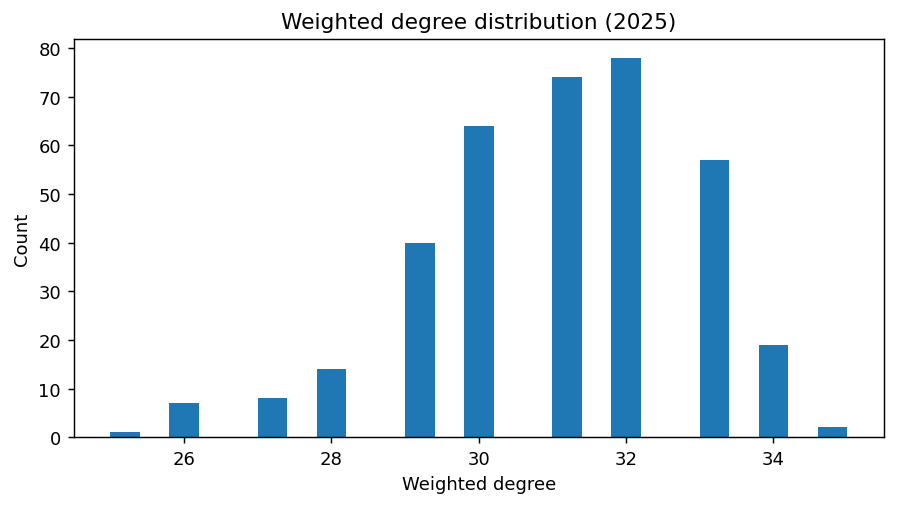

In [25]:
weighted_degree_values = [d for _, d in G.degree(weight="weight")]
plt.figure(figsize=(7, 4))
plt.hist(weighted_degree_values, bins=25)
plt.xlabel("Weighted degree")
plt.ylabel("Count")
finish_figure(f"Weighted degree distribution ({SEASON})", f"weighted_degree_hist_{SEASON}.png")

## 10. Conference meta-graph
This figure compresses the team network into a conference-level network.

Interpretation:
- node size = number of teams in the conference for that season
- edge weight = number of interconference games

Saved: outputs/conference_meta_graph_2025.png


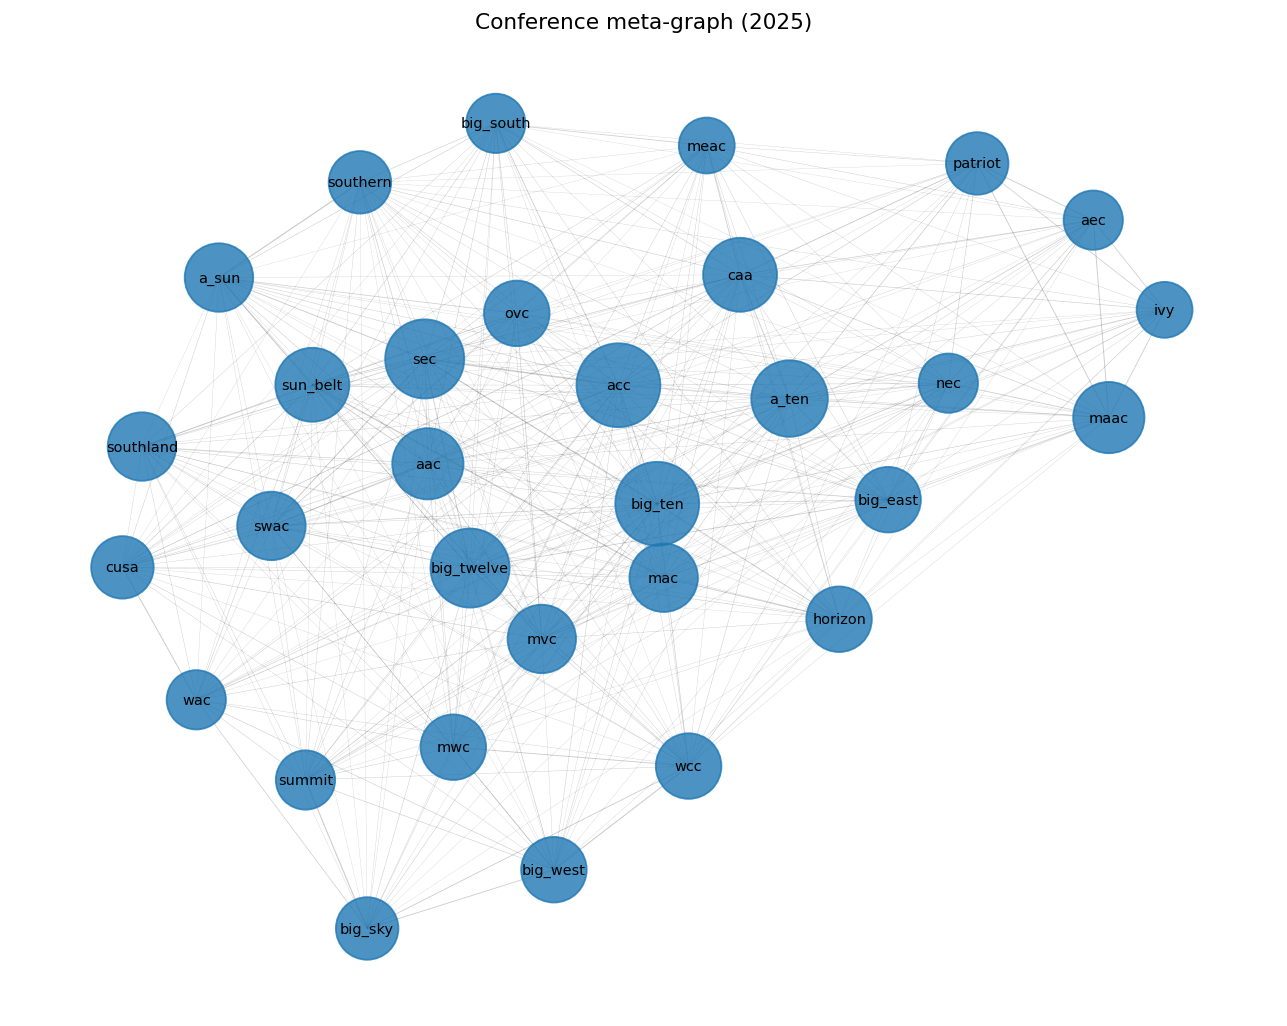

In [26]:
plt.figure(figsize=(10, 8))
pos_c = nx.spring_layout(CG, seed=42, k=0.8, iterations=100, weight="weight")
node_sizes_c = [120 * CG.nodes[n]["size"] for n in CG.nodes()]
edge_widths_c = [0.15 + 0.02 * CG[u][v]["weight"] for u, v in CG.edges()]

nx.draw_networkx_nodes(CG, pos_c, node_size=node_sizes_c, alpha=0.8)
nx.draw_networkx_edges(CG, pos_c, width=edge_widths_c, alpha=0.2)
nx.draw_networkx_labels(CG, pos_c, font_size=8)
plt.axis("off")
finish_figure(f"Conference meta-graph ({SEASON})", f"conference_meta_graph_{SEASON}.png")

## 11. Top teams by centrality
We sort and inspect the most network-central teams for the selected season.

In [27]:
top_weighted_degree = centrality_df.sort_values("WeightedDegree", ascending=False).head(15)
top_betweenness = centrality_df.sort_values("Betweenness", ascending=False).head(15)
top_pagerank = centrality_df.sort_values("PageRank", ascending=False).head(15)

display(top_weighted_degree)
display(top_betweenness)
display(top_pagerank)

save_table(top_weighted_degree, f"top_weighted_degree_{SEASON}")
save_table(top_betweenness, f"top_betweenness_{SEASON}")
save_table(top_pagerank, f"top_pagerank_{SEASON}")

,TeamID,TeamName,Conference,Degree,WeightedDegree,Betweenness,Closeness,PageRank
1,1314,North Carolina,acc,29,35,0.004969,0.446494,0.003566
0,1458,Wisconsin,big_ten,28,35,0.005546,0.455458,0.007719
4,1400,Texas,sec,28,34,0.005448,0.444853,0.007226
13,1166,Creighton,big_east,21,34,0.004264,0.429586,0.006295
3,1397,Tennessee,sec,28,34,0.005658,0.444853,0.018163
6,1272,Memphis,aac,25,34,0.005177,0.443223,0.008874
2,1181,Duke,acc,28,34,0.006057,0.446494,0.009875
18,1337,Pepperdine,wcc,22,34,0.003150,0.410169,0.001457
12,1276,Michigan,big_ten,28,34,0.004453,0.443765,0.009031
19,1174,Delaware,caa,24,34,0.003003,0.418685,0.001986


,TeamID,TeamName,Conference,Degree,WeightedDegree,Betweenness,Closeness,PageRank
21,1390,Stanford,acc,28,33,0.007874,0.443765,0.002603
78,1152,Chicago St,nec,23,32,0.007831,0.457755,0.000606
22,1143,California,acc,28,33,0.006842,0.448148,0.001448
23,1234,Iowa,big_ten,28,33,0.006834,0.454887,0.003087
79,1102,Air Force,mwc,21,32,0.006783,0.437877,0.000751
156,1182,Duquesne,a_ten,26,31,0.006589,0.442683,0.002991
24,1246,Kentucky,sec,28,33,0.006470,0.457755,0.018181
80,1406,Towson,caa,25,32,0.006318,0.445399,0.002490
25,1433,VCU,a_ten,26,33,0.006282,0.437877,0.005000
26,1321,Northwestern,big_ten,28,33,0.006170,0.458913,0.004214


,TeamID,TeamName,Conference,Degree,WeightedDegree,Betweenness,Closeness,PageRank
14,1196,Florida,sec,28,34,0.004177,0.436298,0.019763
39,1120,Auburn,sec,28,33,0.005261,0.457755,0.019432
24,1246,Kentucky,sec,28,33,0.006470,0.457755,0.018181
3,1397,Tennessee,sec,28,34,0.005658,0.444853,0.018163
44,1104,Alabama,sec,28,33,0.005002,0.445399,0.017450
30,1281,Missouri,sec,28,33,0.005710,0.449814,0.012209
127,1401,Texas A&M,sec,28,32,0.003844,0.436298,0.011468
35,1279,Mississippi,sec,28,33,0.005345,0.448702,0.011223
100,1208,Georgia,sec,28,32,0.004851,0.440000,0.010476
31,1277,Michigan St,big_ten,28,33,0.005532,0.457755,0.010062


Saved: outputs/top_weighted_degree_2025.csv
Saved: outputs/top_betweenness_2025.csv
Saved: outputs/top_pagerank_2025.csv


## 12. Bridge-team screening plot
A useful baseline paper figure is a scatter of:
- **weighted degree** on the x-axis,
- **betweenness centrality** on the y-axis.

Teams with unusually high betweenness relative to their weighted degree are good bridge-team candidates.

Saved: outputs/weighted_degree_vs_betweenness_2025.png


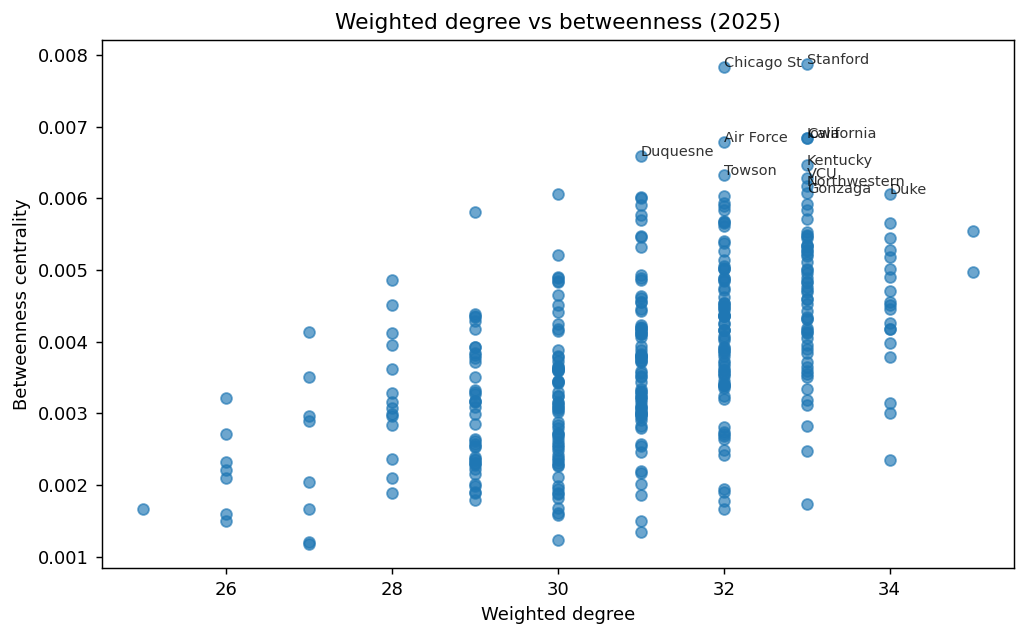

In [28]:
plot_df = centrality_df.copy()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["WeightedDegree"], plot_df["Betweenness"], alpha=0.65)

# annotate a handful of top bridge-like teams
annot_df = plot_df.sort_values(["Betweenness", "WeightedDegree"], ascending=[False, False]).head(12)
for _, row in annot_df.iterrows():
    plt.annotate(
        row["TeamName"],
        (row["WeightedDegree"], row["Betweenness"]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Weighted degree")
plt.ylabel("Betweenness centrality")
finish_figure(f"Weighted degree vs betweenness ({SEASON})",
              f"weighted_degree_vs_betweenness_{SEASON}.png")

## 13. Laplacian-based comparability / embeddedness

This section adds the main spectral quantity for the project. We use the **weighted combinatorial Laplacian** of the schedule graph and its pseudoinverse to build a team-level **comparability score**.

Interpretation used in this notebook:

- A team with **lower** Laplacian-based comparability score is more **embedded** in the national schedule network.
- A team with **higher** score is more **peripheral** or structurally harder to compare to the rest of the field.
- This is a graph-based quantity: it depends on where the team sits in the schedule network, not directly on wins/losses.

We also report the **algebraic connectivity** \(\lambda_2\), which summarizes how well connected the season graph is at a global spectral level.


In [29]:

def laplacian_comparability_table(G):
    """Return a team-level table based on the schedule-graph Laplacian pseudoinverse.

    Comparability score:
        MeanResistanceToField = average effective resistance from a team to all other teams.
    Since row sums of L^+ are zero, this is affine-equivalent to diag(L^+), but it is
    slightly easier to interpret as a global 'distance-to-field' summary.

    Lower score  -> more embedded / more comparable
    Higher score -> more peripheral / less comparable
    """
    nodelist = sorted(G.nodes())
    if not nodelist:
        raise ValueError("Graph is empty; cannot compute Laplacian comparability.")

    # Weighted combinatorial Laplacian
    L = nx.laplacian_matrix(G, nodelist=nodelist, weight="weight").astype(float).toarray()
    L = 0.5 * (L + L.T)  # ensure exact symmetry numerically

    eigvals = np.linalg.eigvalsh(L)
    L_pinv = np.linalg.pinv(L)

    lplus_diag = np.diag(L_pinv)
    trace_lplus = float(np.trace(L_pinv))
    n = len(nodelist)

    if n > 1:
        mean_resistance_to_field = (n * lplus_diag + trace_lplus) / (n - 1)
    else:
        mean_resistance_to_field = lplus_diag.copy()

    rows = []
    for idx, node in enumerate(nodelist):
        rows.append({
            "TeamID": int(node),
            "TeamName": G.nodes[node].get("TeamName", str(node)),
            "Conference": G.nodes[node].get("Conference", "unknown"),
            "LplusDiag": float(lplus_diag[idx]),
            "MeanResistanceToField": float(mean_resistance_to_field[idx]),
            "EmbeddednessScore": float(1.0 / (1e-12 + mean_resistance_to_field[idx])),
        })

    df = pd.DataFrame(rows)
    df["ComparabilityRank"] = df["MeanResistanceToField"].rank(method="min", ascending=True).astype(int)
    return df.sort_values("MeanResistanceToField", ascending=True).reset_index(drop=True), L, L_pinv, eigvals


In [30]:

lap_df, L, L_pinv, eigvals = laplacian_comparability_table(G)

algebraic_connectivity = float(eigvals[1]) if len(eigvals) > 1 else np.nan
spectral_summary = pd.DataFrame([{
    "Season": SEASON,
    "Teams": G.number_of_nodes(),
    "Edges": G.number_of_edges(),
    "AlgebraicConnectivity": algebraic_connectivity,
    "TraceLplus": float(np.trace(L_pinv)),
    "MeanResistanceToField": float(lap_df["MeanResistanceToField"].mean()),
    "MedianResistanceToField": float(lap_df["MeanResistanceToField"].median()),
    "MinResistanceToField": float(lap_df["MeanResistanceToField"].min()),
    "MaxResistanceToField": float(lap_df["MeanResistanceToField"].max()),
}])

lap_centrality_df = centrality_df.merge(
    lap_df,
    on=["TeamID", "TeamName", "Conference"],
    how="left"
)

conference_comparability_df = (
    lap_centrality_df.groupby("Conference")
    .agg(
        Teams=("TeamID", "count"),
        MeanResistanceToField=("MeanResistanceToField", "mean"),
        MedianResistanceToField=("MeanResistanceToField", "median"),
        MeanEmbeddednessScore=("EmbeddednessScore", "mean"),
        MeanWeightedDegree=("WeightedDegree", "mean"),
        MeanBetweenness=("Betweenness", "mean"),
    )
    .reset_index()
    .merge(conf_connectivity_df, on="Conference", how="left")
    .sort_values("MeanResistanceToField", ascending=True)
    .reset_index(drop=True)
)

most_embedded_teams = lap_centrality_df.sort_values("MeanResistanceToField", ascending=True).head(15)
most_peripheral_teams = lap_centrality_df.sort_values("MeanResistanceToField", ascending=False).head(15)

display(spectral_summary)
display(most_embedded_teams[[
    "TeamName", "Conference", "MeanResistanceToField", "LplusDiag",
    "WeightedDegree", "Betweenness", "PageRank"
]])
display(most_peripheral_teams[[
    "TeamName", "Conference", "MeanResistanceToField", "LplusDiag",
    "WeightedDegree", "Betweenness", "PageRank"
]])
display(conference_comparability_df.head(15))
display(conference_comparability_df.tail(15))

save_table(spectral_summary, f"spectral_summary_{SEASON}")
save_table(lap_centrality_df, f"laplacian_centrality_table_{SEASON}")
save_table(conference_comparability_df, f"conference_comparability_{SEASON}")


,Season,Teams,Edges,AlgebraicConnectivity,TraceLplus,MeanResistanceToField,MedianResistanceToField,MinResistanceToField,MaxResistanceToField
0,2025,364,4043,4.387753,13.259468,0.073055,0.072927,0.067662,0.081652


,TeamName,Conference,MeanResistanceToField,LplusDiag,WeightedDegree,Betweenness,PageRank
1,North Carolina,acc,0.067662,0.031049,35,0.004969,0.003566
0,Wisconsin,big_ten,0.067701,0.031087,35,0.005546,0.007719
3,Tennessee,sec,0.068341,0.031727,34,0.005658,0.018163
4,Texas,sec,0.068379,0.031764,34,0.005448,0.007226
14,Florida,sec,0.068430,0.031815,34,0.004177,0.019763
2,Duke,acc,0.068555,0.031940,34,0.006057,0.009875
12,Michigan,big_ten,0.068558,0.031943,34,0.004453,0.009031
15,Louisville,acc,0.068628,0.032012,34,0.004173,0.006060
8,Houston,big_twelve,0.068899,0.032282,34,0.004903,0.008667
6,Memphis,aac,0.068958,0.032341,34,0.005177,0.008874


,TeamName,Conference,MeanResistanceToField,LplusDiag,WeightedDegree,Betweenness,PageRank
363,Columbia,ivy,0.081652,0.045000,25,0.001668,0.001172
361,Citadel,southern,0.081237,0.044587,26,0.001597,0.000434
359,Dartmouth,ivy,0.080432,0.043784,26,0.002211,0.001534
358,Oral Roberts,summit,0.080185,0.043538,26,0.002319,0.000743
354,Idaho St,big_sky,0.080081,0.043434,27,0.001212,0.001076
362,Wagner,nec,0.080065,0.043418,26,0.001502,0.000988
360,Brown,ivy,0.080055,0.043408,26,0.002104,0.001591
357,Harvard,ivy,0.079902,0.043255,26,0.002718,0.001620
353,W Carolina,southern,0.079496,0.042851,27,0.001671,0.000639
351,UTRGV,southland,0.079369,0.042724,27,0.002890,0.000925


,Conference,Teams,MeanResistanceToField,MedianResistanceToField,MeanEmbeddednessScore,MeanWeightedDegree,MeanBetweenness,TeamsInSeason,InterconfDegree,InterconfWeightedDegree
0,sec,16,0.069295,0.069145,14.432070,32.875000,0.004919,16,28,208
1,acc,18,0.069790,0.069452,14.331454,32.611111,0.005115,18,30,199
2,big_ten,18,0.069857,0.069437,14.318162,32.500000,0.005526,18,30,197
3,big_twelve,16,0.070071,0.069881,14.272386,32.812500,0.004573,16,28,171
4,a_ten,15,0.071011,0.070942,14.085358,31.733333,0.005178,15,27,176
5,big_east,11,0.071156,0.070993,14.054651,32.818182,0.003819,11,24,121
6,caa,14,0.071598,0.071533,13.970944,31.428571,0.004400,14,26,162
7,aac,13,0.071718,0.071882,13.948395,31.384615,0.004264,13,27,150
8,wcc,11,0.071936,0.071672,13.904419,31.909091,0.004198,11,27,133
9,sun_belt,14,0.072323,0.072313,13.831130,31.000000,0.003767,14,25,156


,Conference,Teams,MeanResistanceToField,MedianResistanceToField,MeanEmbeddednessScore,MeanWeightedDegree,MeanBetweenness,TeamsInSeason,InterconfDegree,InterconfWeightedDegree
16,patriot,10,0.073977,0.073371,13.526805,31.000000,0.002662,10,19,112
17,wac,9,0.074027,0.074226,13.514424,30.111111,0.003886,9,22,111
18,big_south,9,0.074111,0.073821,13.498956,30.000000,0.003435,9,23,110
19,aec,9,0.074180,0.073804,13.484660,30.333333,0.002839,9,20,115
20,horizon,11,0.074269,0.074231,13.469017,31.000000,0.003181,11,28,101
21,big_west,11,0.074466,0.074348,13.434676,31.090909,0.002664,11,22,108
22,nec,9,0.074670,0.074350,13.404992,29.666667,0.004065,9,27,109
23,cusa,10,0.074744,0.074719,13.380853,30.100000,0.003285,10,24,103
24,summit,9,0.075339,0.075552,13.283150,29.444444,0.003571,9,24,105
25,southern,10,0.075759,0.074914,13.213602,29.700000,0.003240,10,28,99


Saved: outputs/spectral_summary_2025.csv
Saved: outputs/laplacian_centrality_table_2025.csv
Saved: outputs/conference_comparability_2025.csv


Saved: outputs/laplacian_comparability_hist_2025.png


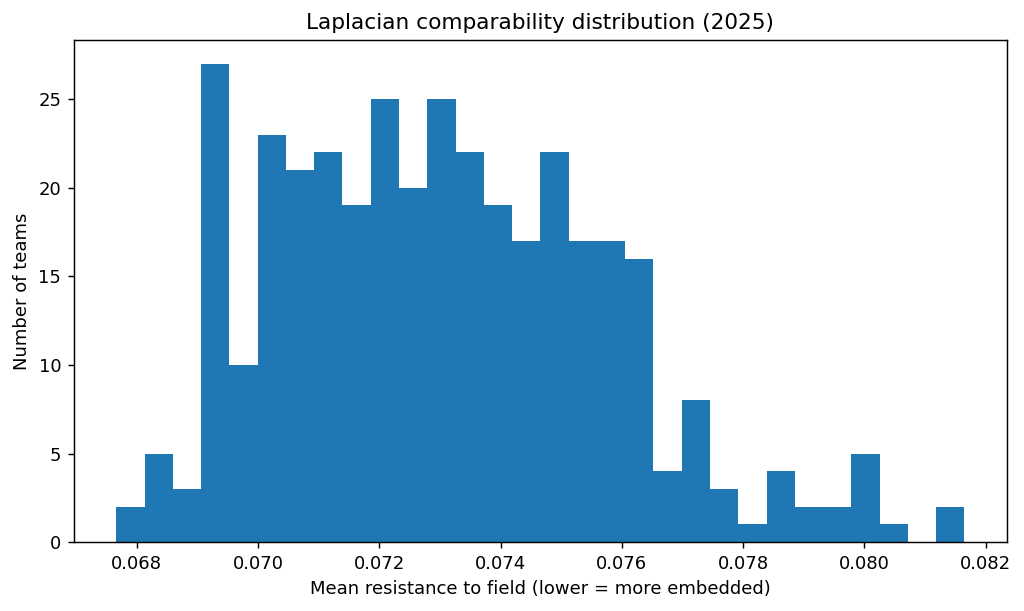

Saved: outputs/weighted_degree_vs_laplacian_2025.png


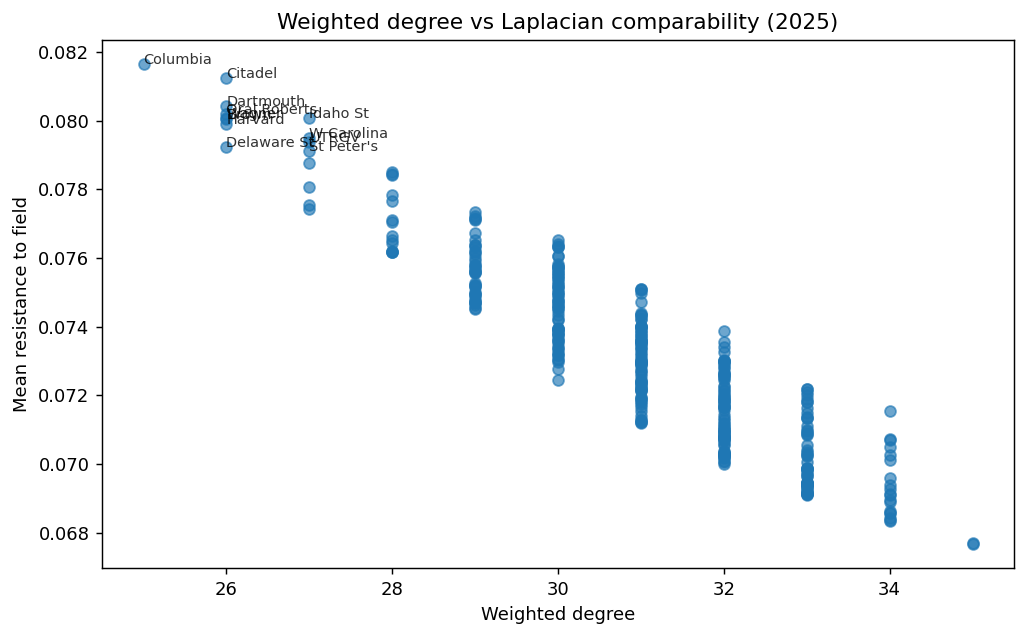

Saved: outputs/betweenness_vs_laplacian_2025.png


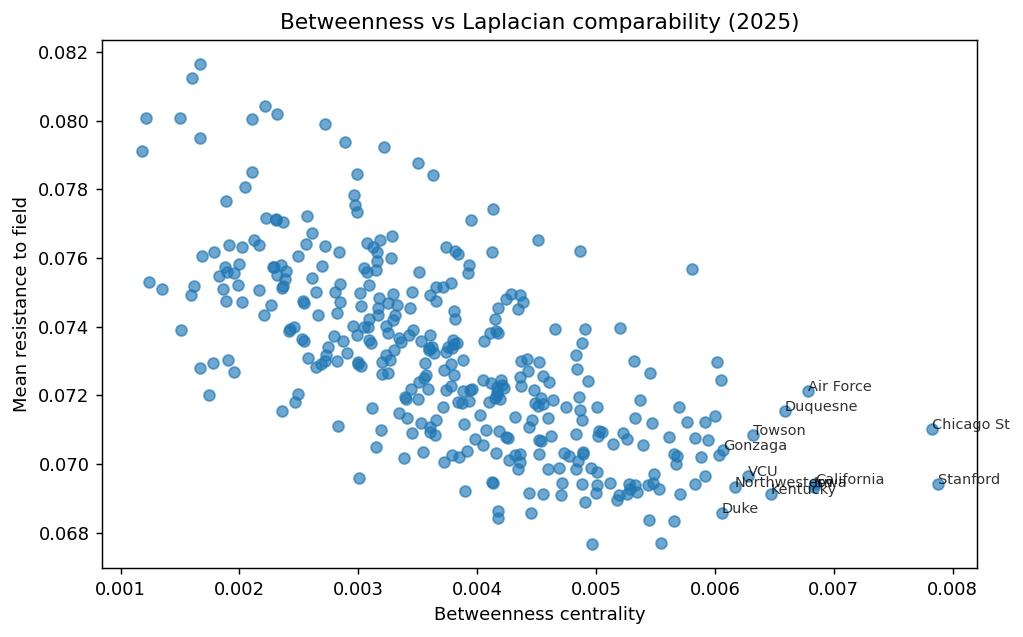

Saved: outputs/conference_comparability_2025.png


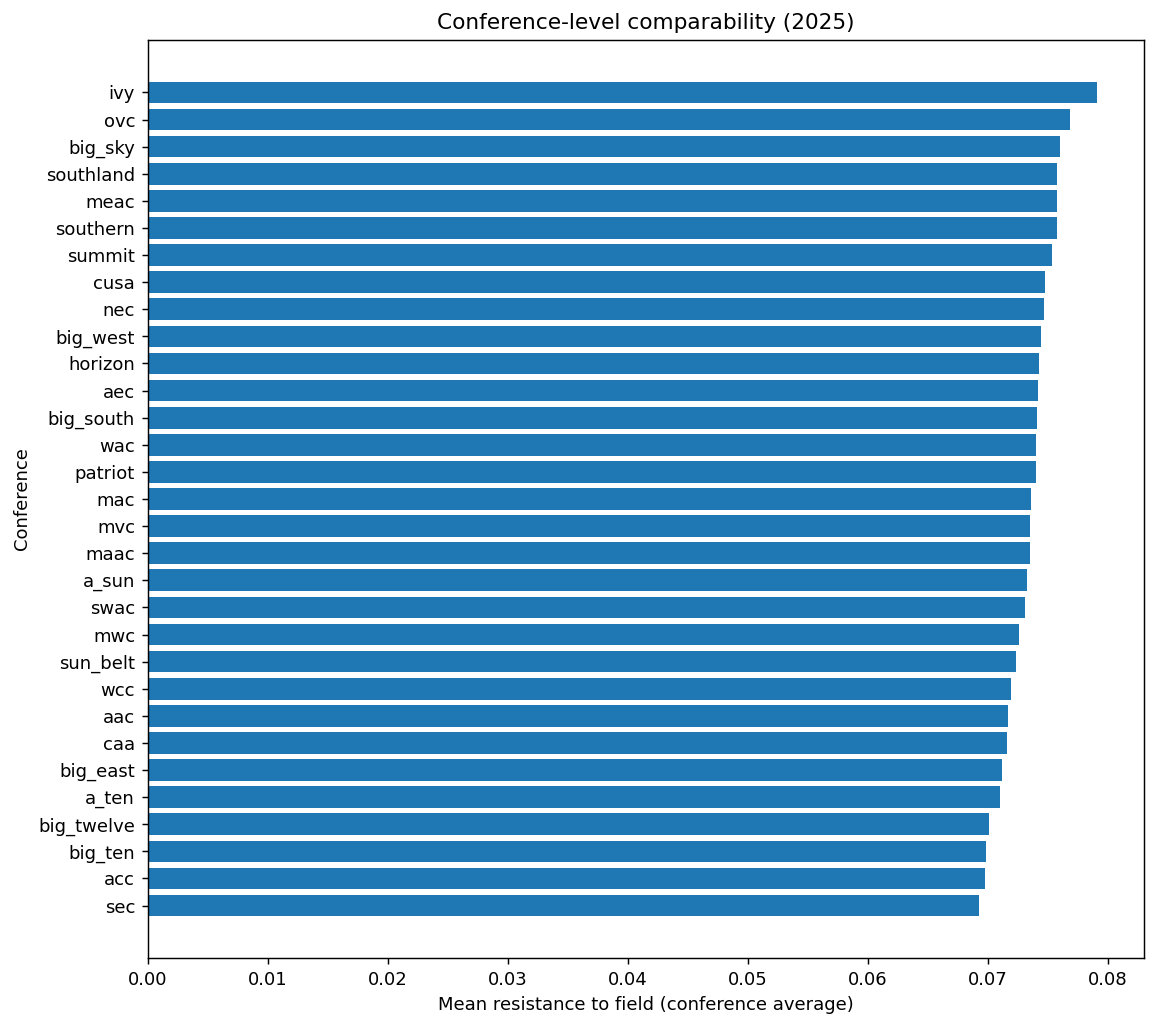

In [31]:

plt.figure(figsize=(8, 4.8))
plt.hist(lap_centrality_df["MeanResistanceToField"], bins=30)
plt.xlabel("Mean resistance to field (lower = more embedded)")
plt.ylabel("Number of teams")
finish_figure(
    f"Laplacian comparability distribution ({SEASON})",
    f"laplacian_comparability_hist_{SEASON}.png"
)

plt.figure(figsize=(8, 5))
plt.scatter(
    lap_centrality_df["WeightedDegree"],
    lap_centrality_df["MeanResistanceToField"],
    alpha=0.65
)

annot_df = lap_centrality_df.sort_values("MeanResistanceToField", ascending=False).head(12)
for _, row in annot_df.iterrows():
    plt.annotate(
        row["TeamName"],
        (row["WeightedDegree"], row["MeanResistanceToField"]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Weighted degree")
plt.ylabel("Mean resistance to field")
finish_figure(
    f"Weighted degree vs Laplacian comparability ({SEASON})",
    f"weighted_degree_vs_laplacian_{SEASON}.png"
)

plt.figure(figsize=(8, 5))
plt.scatter(
    lap_centrality_df["Betweenness"],
    lap_centrality_df["MeanResistanceToField"],
    alpha=0.65
)

annot_df = lap_centrality_df.sort_values(
    ["Betweenness", "MeanResistanceToField"],
    ascending=[False, False]
).head(12)
for _, row in annot_df.iterrows():
    plt.annotate(
        row["TeamName"],
        (row["Betweenness"], row["MeanResistanceToField"]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Betweenness centrality")
plt.ylabel("Mean resistance to field")
finish_figure(
    f"Betweenness vs Laplacian comparability ({SEASON})",
    f"betweenness_vs_laplacian_{SEASON}.png"
)

plot_conf_df = conference_comparability_df.sort_values("MeanResistanceToField", ascending=True).copy()
plt.figure(figsize=(9, 8))
plt.barh(plot_conf_df["Conference"], plot_conf_df["MeanResistanceToField"])
plt.xlabel("Mean resistance to field (conference average)")
plt.ylabel("Conference")
finish_figure(
    f"Conference-level comparability ({SEASON})",
    f"conference_comparability_{SEASON}.png"
)


## 14. Null-model comparison (Erdős–Rényi and degree-preserving)

This section asks whether the observed schedule topology is genuinely structured, or whether similar patterns would arise in simple random graph baselines.

To stay close to standard network-science null models, we work with the **unweighted schedule topology** here:
- **Erdős–Rényi** baseline with the same number of nodes and approximately the same density.
- **Degree-preserving** baseline using a random simple graph with the same degree sequence as the observed schedule graph.

We then compare the observed graph to the null samples on three quantities that are especially relevant to the course:
- **Average clustering**
- **Average path length on the giant connected component**
- **Conference modularity** under the real conference partition

If the observed graph has much higher modularity and clustering than both null families, that supports the claim that conference organization is a real network feature rather than a generic consequence of graph size or degree heterogeneity.


In [32]:
# Null-model configuration
NULL_SAMPLE_COUNT = 20
NULL_BASE_SEED = 168

def conference_partition_from_graph(G):
    communities = {}
    for node, data in G.nodes(data=True):
        communities.setdefault(data.get("Conference", "unknown"), []).append(node)
    return list(communities.values())

def simple_graph_metrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)
    avg_degree = np.mean([d for _, d in G.degree()]) if n else np.nan
    avg_clustering = nx.average_clustering(G)

    components = list(nx.connected_components(G))
    gcc_nodes = max(components, key=len)
    G_gcc = G.subgraph(gcc_nodes).copy()

    avg_path = nx.average_shortest_path_length(G_gcc) if len(G_gcc) > 1 else np.nan
    gcc_share = len(gcc_nodes) / n if n else np.nan

    conference_partition = conference_partition_from_graph(G)
    conf_modularity = modularity(G, conference_partition, weight=None)

    return {
        "Nodes": n,
        "Edges": m,
        "Density": density,
        "AvgDegree": avg_degree,
        "GCCShare": gcc_share,
        "AvgClustering": avg_clustering,
        "AvgPathLength_GCC": avg_path,
        "ConferenceModularity_Unweighted": conf_modularity,
    }

def relabel_and_copy_attrs(H, nodelist, original_graph):
    mapping = {i: node for i, node in enumerate(nodelist)}
    H = nx.relabel_nodes(H, mapping)

    attrs = {
        node: {
            "TeamName": original_graph.nodes[node].get("TeamName"),
            "Conference": original_graph.nodes[node].get("Conference", "unknown"),
        }
        for node in H.nodes()
    }
    nx.set_node_attributes(H, attrs)
    return H

def sample_er_null_graph(G, seed):
    nodelist = sorted(G.nodes())
    n = len(nodelist)
    m = G.number_of_edges()
    p = 2 * m / (n * (n - 1))

    H = nx.gnp_random_graph(n, p, seed=seed)
    return relabel_and_copy_attrs(H, nodelist, G)

def sample_degree_preserving_null_graph(G, seed, tries=200, max_attempts=5):
    nodelist = sorted(G.nodes())
    degree_sequence = [G.degree(node) for node in nodelist]

    last_err = None
    for attempt in range(max_attempts):
        try_seed = seed + attempt
        try:
            H = nx.random_degree_sequence_graph(degree_sequence, seed=try_seed, tries=tries)
            return relabel_and_copy_attrs(H, nodelist, G)
        except Exception as err:
            last_err = err

    raise RuntimeError(f"Degree-preserving null model failed after {max_attempts} attempts: {last_err}")

def null_model_comparison_table(G, n_samples=20, base_seed=168):
    observed = simple_graph_metrics(G)
    rows = [{"Model": "Observed", "Sample": -1, **observed}]

    for model_name in ["Erdos-Renyi", "Degree-Preserving"]:
        for s in range(n_samples):
            seed = base_seed + 1000 * (1 if model_name == "Erdos-Renyi" else 2) + s

            if model_name == "Erdos-Renyi":
                H = sample_er_null_graph(G, seed=seed)
            else:
                H = sample_degree_preserving_null_graph(G, seed=seed, tries=200)

            rows.append({
                "Model": model_name,
                "Sample": s,
                **simple_graph_metrics(H),
            })

    return pd.DataFrame(rows)

def summarize_null_results(null_df, metrics):
    observed = null_df.loc[null_df["Model"] == "Observed"].iloc[0]
    rows = []

    for model_name in [m for m in null_df["Model"].unique() if m != "Observed"]:
        model_df = null_df.loc[null_df["Model"] == model_name]

        for metric in metrics:
            values = model_df[metric].dropna().to_numpy(dtype=float)
            obs = float(observed[metric])

            null_mean = float(values.mean())
            null_std = float(values.std(ddof=1)) if len(values) > 1 else np.nan
            z_score = (obs - null_mean) / null_std if null_std and not np.isnan(null_std) and null_std > 0 else np.nan

            rows.append({
                "Model": model_name,
                "Metric": metric,
                "Observed": obs,
                "NullMean": null_mean,
                "NullStd": null_std,
                "ZScore_vsNull": z_score,
                "EmpiricalPercentile": float(np.mean(values <= obs)),
                "NullMin": float(values.min()),
                "NullMax": float(values.max()),
            })

    return pd.DataFrame(rows)


In [33]:
null_metrics = [
    "AvgClustering",
    "AvgPathLength_GCC",
    "ConferenceModularity_Unweighted",
]

null_df = null_model_comparison_table(
    G,
    n_samples=NULL_SAMPLE_COUNT,
    base_seed=NULL_BASE_SEED,
)

null_summary_df = summarize_null_results(null_df, metrics=null_metrics)

display(null_summary_df.sort_values(["Metric", "Model"]).reset_index(drop=True))

save_table(null_df, f"null_model_samples_{SEASON}")
save_table(null_summary_df, f"null_model_summary_{SEASON}")


,Model,Metric,Observed,NullMean,NullStd,ZScore_vsNull,EmpiricalPercentile,NullMin,NullMax
0,Degree-Preserving,AvgClustering,0.310107,0.058441,0.001437,175.089076,1.0,0.055729,0.061082
1,Erdos-Renyi,AvgClustering,0.310107,0.061466,0.001789,138.980079,1.0,0.058041,0.065166
2,Degree-Preserving,AvgPathLength_GCC,2.374868,2.176604,0.001438,137.903374,1.0,2.174961,2.179533
3,Erdos-Renyi,AvgPathLength_GCC,2.374868,2.178515,0.012074,16.262637,1.0,2.162580,2.209291
4,Degree-Preserving,ConferenceModularity_Unweighted,0.472568,-0.002537,0.002772,171.389805,1.0,-0.007026,0.004599
5,Erdos-Renyi,ConferenceModularity_Unweighted,0.472568,-0.002658,0.002522,188.451747,1.0,-0.006713,0.001263


Saved: outputs/null_model_samples_2025.csv
Saved: outputs/null_model_summary_2025.csv


/tmp/ipykernel_16540/1954843259.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=model_order, showfliers=False)
/tmp/ipykernel_16540/1954843259.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=model_order, showfliers=False)
/tmp/ipykernel_16540/1954843259.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=model_order, showfliers=False)


Saved: outputs/null_model_comparison_boxplots_2025.png


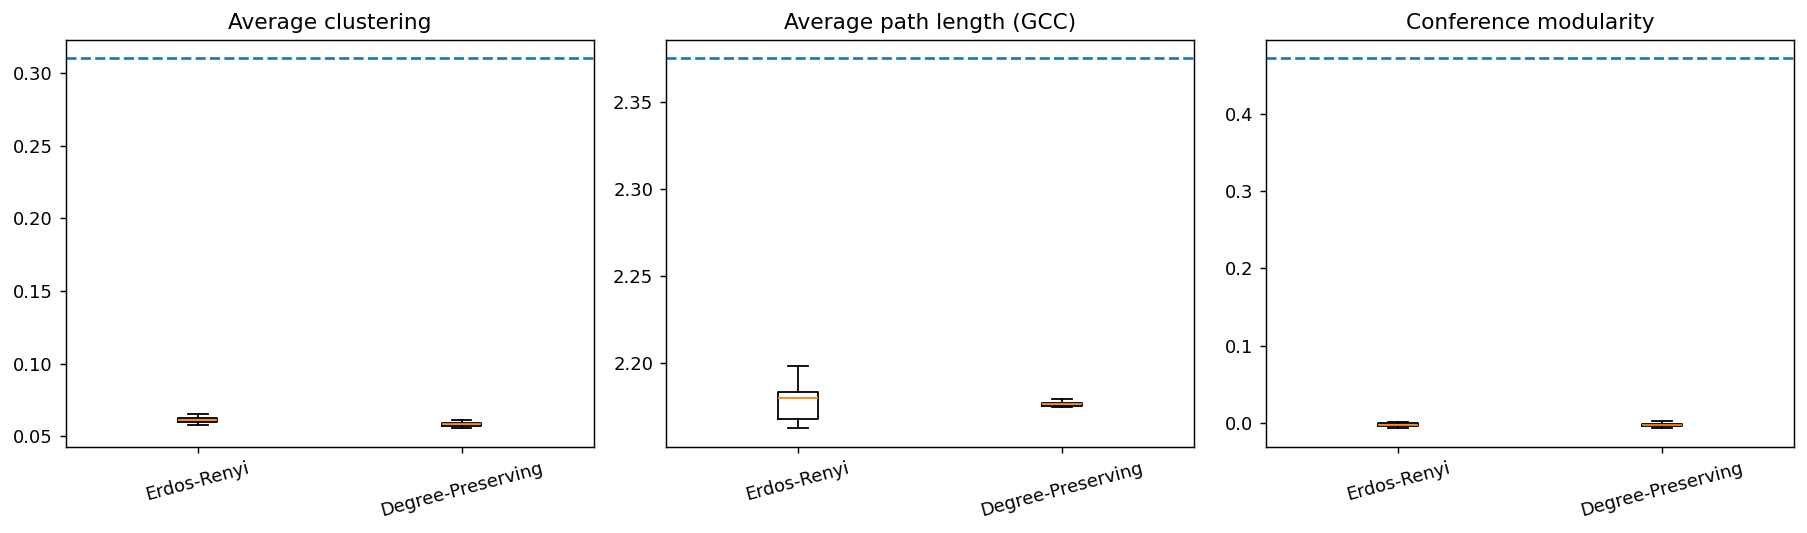

In [34]:
metric_labels = {
    "AvgClustering": "Average clustering",
    "AvgPathLength_GCC": "Average path length (GCC)",
    "ConferenceModularity_Unweighted": "Conference modularity",
}

observed_row = null_df.loc[null_df["Model"] == "Observed"].iloc[0]
model_order = ["Erdos-Renyi", "Degree-Preserving"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, metric in zip(axes, null_metrics):
    data = [
        null_df.loc[null_df["Model"] == model_name, metric].to_numpy(dtype=float)
        for model_name in model_order
    ]
    ax.boxplot(data, labels=model_order, showfliers=False)
    ax.axhline(float(observed_row[metric]), linestyle="--", linewidth=1.5)
    ax.set_title(metric_labels[metric])
    ax.tick_params(axis="x", rotation=15)

finish_figure(filename=f"null_model_comparison_boxplots_{SEASON}.png")


In [35]:
null_summary_pivot = (
    null_summary_df.pivot(index="Metric", columns="Model", values=["Observed", "NullMean", "ZScore_vsNull", "EmpiricalPercentile"])
    .sort_index()
)

display(null_summary_pivot)
save_table(null_summary_pivot.reset_index(), f"null_model_summary_pivot_{SEASON}")


Observed              \
Model                           Degree-Preserving Erdos-Renyi   
Metric                                                          
AvgClustering                            0.310107    0.310107   
AvgPathLength_GCC                        2.374868    2.374868   
ConferenceModularity_Unweighted          0.472568    0.472568   

                                         NullMean              \
Model                           Degree-Preserving Erdos-Renyi   
Metric                                                          
AvgClustering                            0.058441    0.061466   
AvgPathLength_GCC                        2.176604    2.178515   
ConferenceModularity_Unweighted         -0.002537   -0.002658   

                                    ZScore_vsNull              \
Model                           Degree-Preserving Erdos-Renyi   
Metric                                                          
AvgClustering                          175.089076  138.980079   
AvgPathLength_GCC                      137.903374   16.262637   
ConferenceModularity_Unweighted        171.389805  188.451747   

                                EmpiricalPercentile              
Model                             Degree-Preserving Erdos-Renyi  
Metric                                                           
AvgClustering                                   1.0         1.0  
AvgPathLength_GCC                               1.0         1.0  
ConferenceModularity_Unweighted                 1.0         1.0

Saved: outputs/null_model_summary_pivot_2025.csv


## 15. Updated interpretation notes for the paper draft

At this point, the notebook supports four layers of results:

1. **Community structure:** the NCAA schedule graph is strongly modular along conference lines.  
2. **Bridge structure:** some teams and conferences are disproportionately important for connecting those communities.  
3. **Spectral comparability:** Laplacian-based scores quantify which teams are most embedded in, or most peripheral to, the national schedule network.  
4. **Null-model comparison:** the observed schedule graph can be compared to Erdős–Rényi and degree-preserving baselines to show that its clustering and conference modularity are not generic random-graph artifacts.

This gives the project a clear progression from descriptive network structure to a more mathematical notion of global comparability, and then to a baseline-vs-null argument that the structure is genuinely non-random.


## 16. Suggested next notebook / next section

The strongest next extension after the null-model section would be one of these:

- **Detected communities vs. real conferences:** compare algorithmic community detection to the known conference partition.
- **Conference-level bridge dependence:** quantify whether a few teams carry a disproportionate share of each conference's cross-conference connectivity.
- **Robustness with detailed results:** use score margin or location-aware variants from the detailed-results file.

For the final report, we will likely keep only the most compact and persuasive subset of the notebook outputs.
